# 📊 Marketing A/B Testing Analysis

**Objective:** Evaluate whether showing ads (Ad group) produces a significantly higher conversion rate than showing public service announcements (PSA group), and extract actionable business insights.

| Column | Description |
|---|---|
| `user id` | Unique customer identifier |
| `test group` | `ad` = saw advertisement · `psa` = saw public service announcement |
| `converted` | `True` if the customer made a purchase |
| `total ads` | Number of ads seen by the user |
| `most ads day` | Day of the week the user saw the most ads |
| `most ads hour` | Hour of the day the user saw the most ads |

---

## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
COLORS = {"ad": "#4C72B0", "psa": "#DD8452", "yes": "#2ecc71", "no": "#e74c3c"}

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv("marketing_AB.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")  # drop index artifact

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 588,101 rows × 6 columns


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


---
## 2 · Data Quality Check

In [2]:
# ── Data types & missing values ────────────────────────────────────────────
quality = pd.DataFrame({
    "Data Type":        df.dtypes,
    "Missing Values":   df.isnull().sum(),
    "Missing %":        (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values":    df.nunique(),
})
quality

,Data Type,Missing Values,Missing %,Unique Values
user id,int64,0,0.0,588101
test group,object,0,0.0,2
converted,bool,0,0.0,2
total ads,int64,0,0.0,807
most ads day,object,0,0.0,7
most ads hour,int64,0,0.0,24


In [3]:
# ── Duplicates ─────────────────────────────────────────────────────────────
dup_rows = df.duplicated().sum()
dup_ids  = df["user id"].duplicated().sum()
print(f"Duplicate rows   : {dup_rows}")
print(f"Duplicate user IDs: {dup_ids}")

if dup_rows > 0:
    df = df.drop_duplicates()
    print(f"→ Removed duplicates. New shape: {df.shape}")

Duplicate rows   : 0
Duplicate user IDs: 0


In [4]:
# ── Outliers (IQR method) ──────────────────────────────────────────────────
num_cols = df.select_dtypes(include="number").columns
outlier_report = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report.append({"Column": col, "Outliers": n, "Outlier %": round(n/len(df)*100, 2)})

pd.DataFrame(outlier_report)

,Column,Outliers,Outlier %
0,user id,0,0.00
1,total ads,52057,8.85
2,most ads hour,5536,0.94


<Axes: >

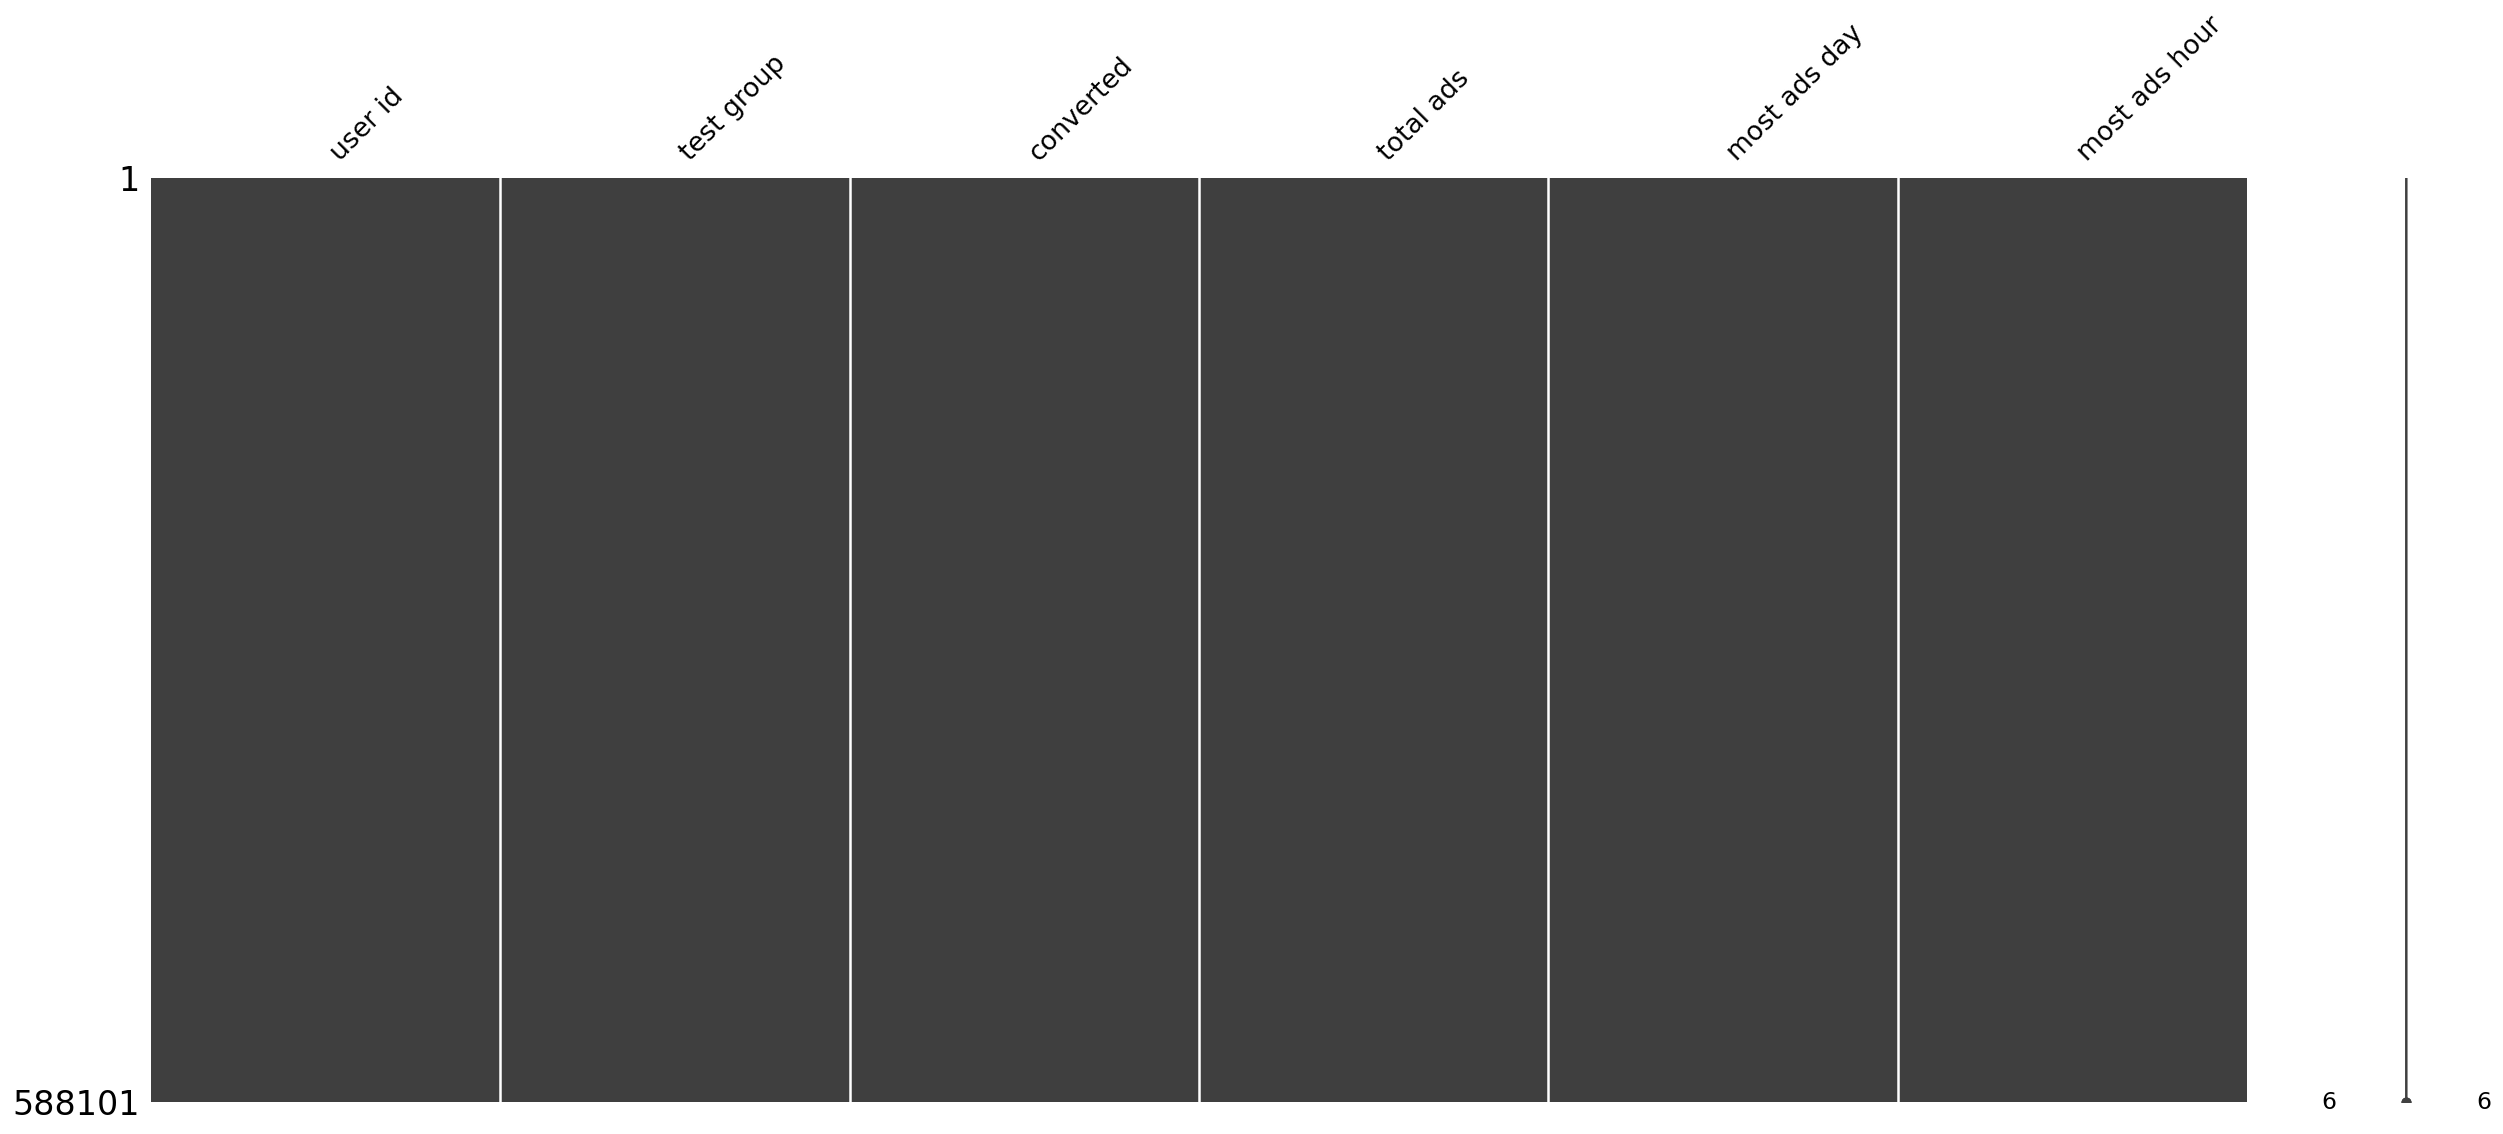

In [20]:
import missingno as msno

msno.matrix(df)

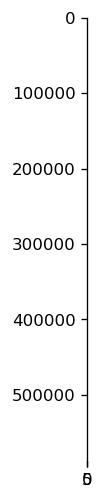

In [21]:
plt.imshow(df.isnull())

In [5]:
# ── Value validation ───────────────────────────────────────────────────────
valid_days  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
invalid_days  = df[~df["most ads day"].isin(valid_days)]
invalid_hours = df[(df["most ads hour"] < 0) | (df["most ads hour"] > 23)]
negative_ads  = df[df["total ads"] < 0]

print(f"Invalid days  : {len(invalid_days)}")
print(f"Invalid hours : {len(invalid_hours)}")
print(f"Negative ads  : {len(negative_ads)}")
print("\n✅ No impossible values found." if all(len(x)==0 for x in [invalid_days, invalid_hours, negative_ads])
      else "⚠️  Investigate the rows above.")

Invalid days  : 0
Invalid hours : 0
Negative ads  : 0

✅ No impossible values found.


---
## 3 · Exploratory Data Analysis

### 3.1 Descriptive Statistics

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user id,588101.0,NaN,NaN,NaN,1310692.215793,202225.983128,900000.0,1143190.0,1313725.0,1484088.0,1654483.0
test group,588101,2,ad,564577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
converted,588101,2,False,573258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total ads,588101.0,NaN,NaN,NaN,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads day,588101,7,Friday,92608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
most ads hour,588101.0,NaN,NaN,NaN,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


### 3.2 Test Group Balance

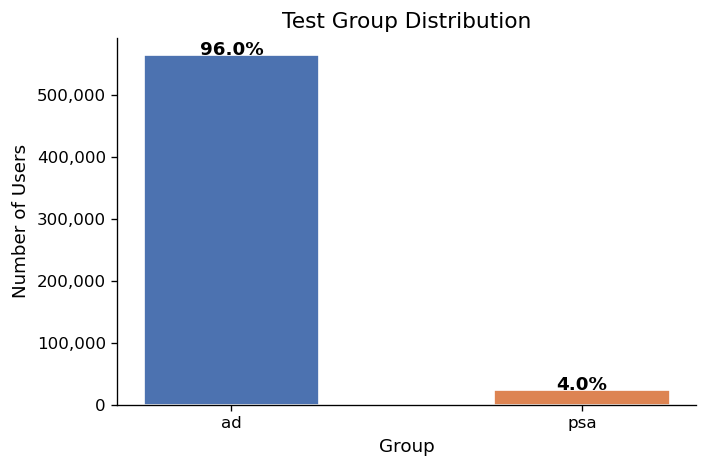

test group
ad     564577
psa     23524


In [7]:
group_counts = df["test group"].value_counts()
group_pct    = (group_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(group_counts.index, group_counts.values,
              color=[COLORS["ad"], COLORS["psa"]], edgecolor="white", width=0.5)
for bar, pct in zip(bars, group_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{pct}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Test Group Distribution")
ax.set_xlabel("Group")
ax.set_ylabel("Number of Users")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(group_counts.to_string())

### 3.3 Conversion Rate Overview

Total users       : 588,101
Converted users   : 14,843
Overall conv. rate: 2.52%


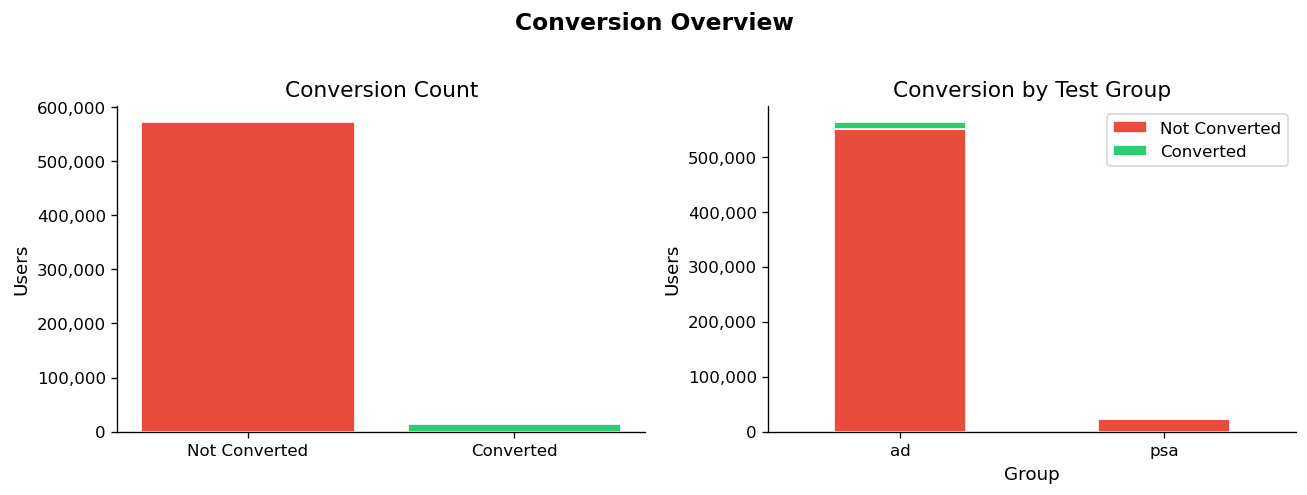

In [8]:
overall_cr = df["converted"].mean() * 100
converted  = df["converted"].sum()
total      = len(df)

print(f"Total users       : {total:,}")
print(f"Converted users   : {int(converted):,}")
print(f"Overall conv. rate: {overall_cr:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left — absolute counts
counts = df["converted"].value_counts()
axes[0].bar(["Not Converted", "Converted"], counts.values,
            color=[COLORS["no"], COLORS["yes"]], edgecolor="white")
axes[0].set_title("Conversion Count")
axes[0].set_ylabel("Users")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right — by test group (stacked)
ct = pd.crosstab(df["test group"], df["converted"])
ct.plot(kind="bar", stacked=True, ax=axes[1],
        color=[COLORS["no"], COLORS["yes"]], edgecolor="white", legend=False)
axes[1].set_title("Conversion by Test Group")
axes[1].set_ylabel("Users")
axes[1].set_xlabel("Group")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Not Converted", "Converted"], loc="upper right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Conversion Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Total Ads Distribution

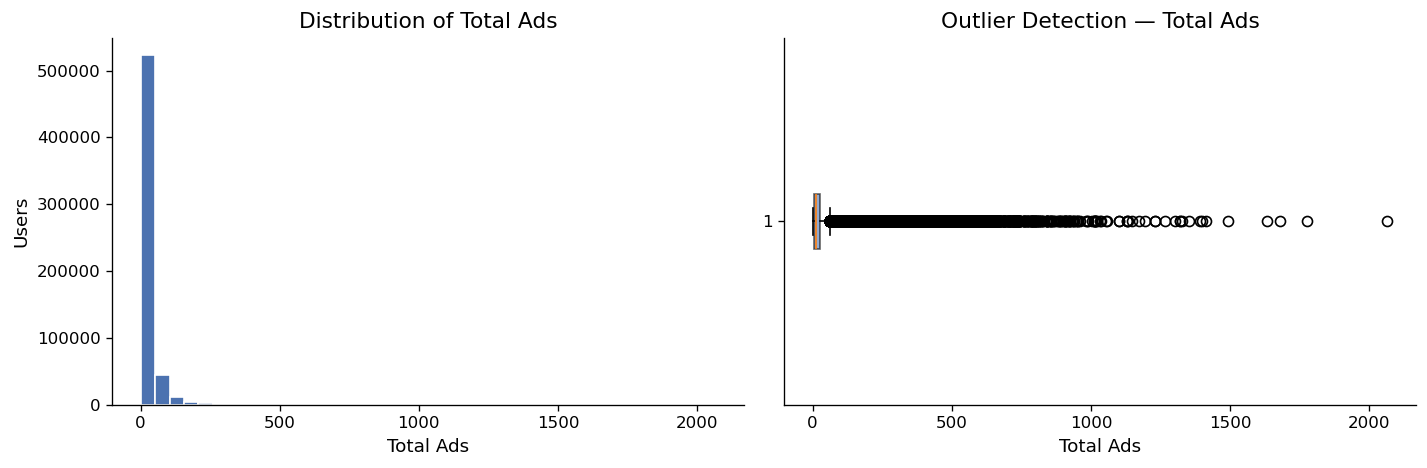

count    588101.00
mean         24.82
std          43.72
min           1.00
25%           4.00
50%          13.00
75%          27.00
max        2065.00
Name: total ads, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["total ads"], bins=40, edgecolor="white", color="#4C72B0")
axes[0].set_title("Distribution of Total Ads")
axes[0].set_xlabel("Total Ads")
axes[0].set_ylabel("Users")

axes[1].boxplot(df["total ads"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[1].set_title("Outlier Detection — Total Ads")
axes[1].set_xlabel("Total Ads")

plt.tight_layout()
plt.show()

print(df["total ads"].describe().round(2))

### 3.5 Ad Exposure by Day & Hour

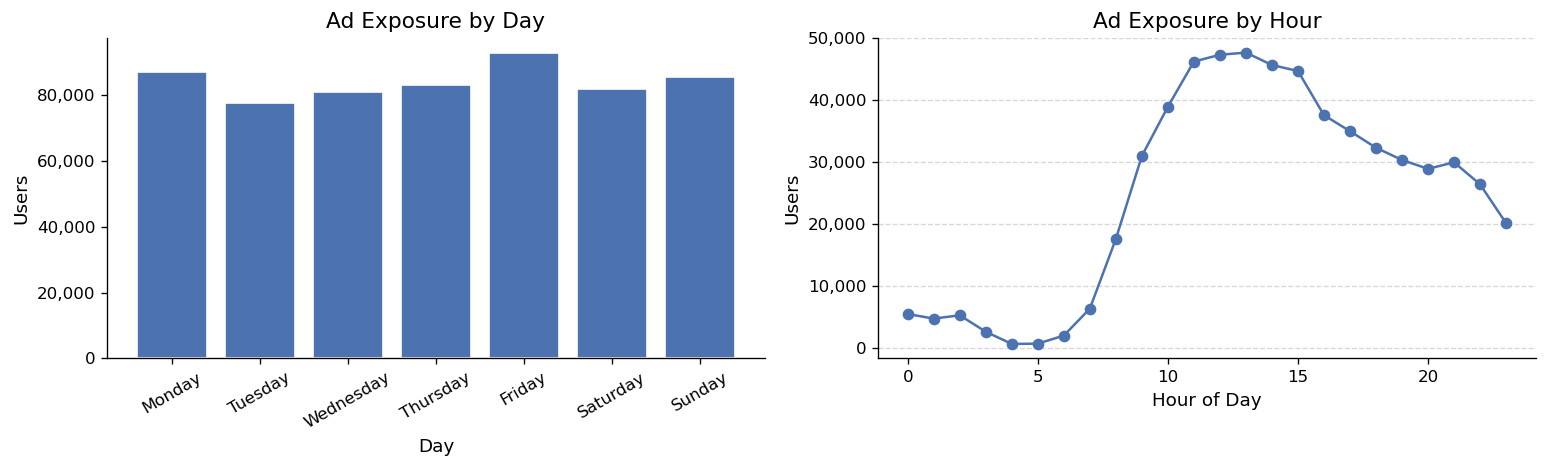

In [10]:
DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Day
day_counts = df["most ads day"].value_counts().reindex(DAY_ORDER)
axes[0].bar(DAY_ORDER, day_counts.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Ad Exposure by Day")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Hour
hour_counts = df["most ads hour"].value_counts().sort_index()
axes[1].plot(hour_counts.index, hour_counts.values, marker="o", color="#4C72B0")
axes[1].set_title("Ad Exposure by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Users")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

### 3.6 Conversion Rate by Day & Hour

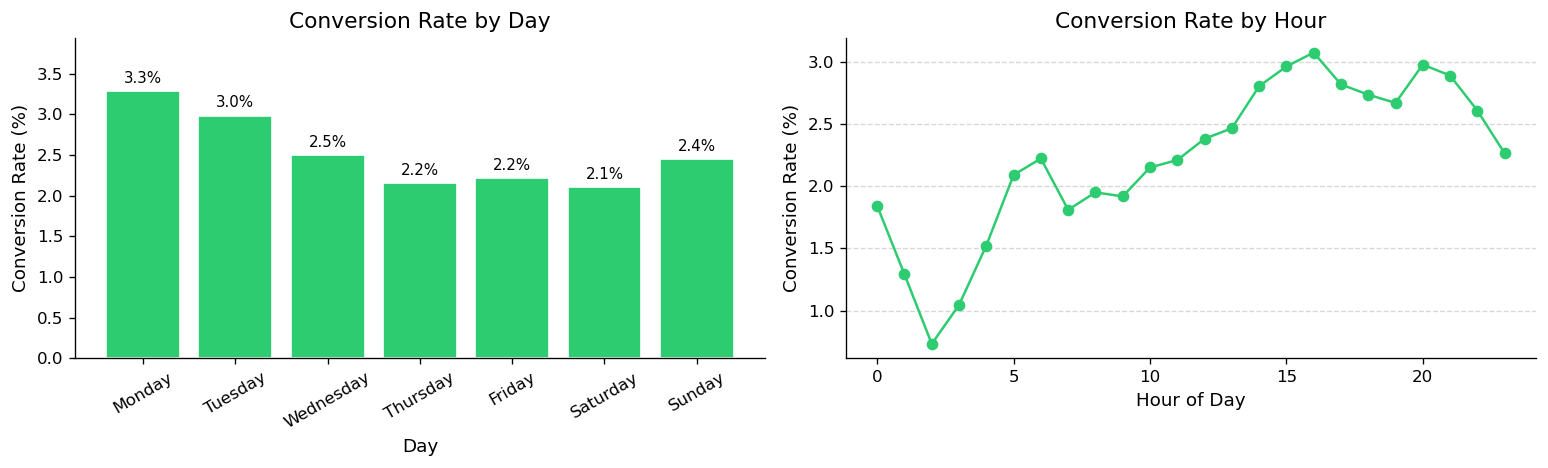

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

day_cr = df.groupby("most ads day")["converted"].mean().reindex(DAY_ORDER) * 100
axes[0].bar(DAY_ORDER, day_cr.values, color="#2ecc71", edgecolor="white")
axes[0].set_title("Conversion Rate by Day")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylim(0, day_cr.max() * 1.2)
for i, v in enumerate(day_cr.values):
    axes[0].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)

hour_cr = df.groupby("most ads hour")["converted"].mean() * 100
axes[1].plot(hour_cr.index, hour_cr.values, marker="o", color="#2ecc71")
axes[1].set_title("Conversion Rate by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 3.7 Correlation Heatmap

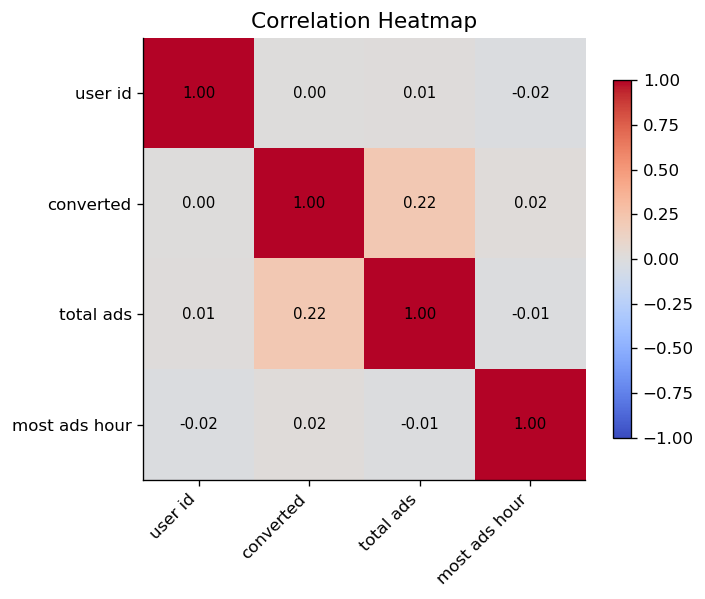

In [12]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

---
## 4 · Campaign Performance Summary

In [13]:
campaign = df.groupby("test group").agg(
    Total_Users  = ("user id",   "count"),
    Conversions  = ("converted", "sum"),
    Avg_Ads      = ("total ads", "mean"),
)
campaign["Conversion Rate (%)"] = (campaign["Conversions"] / campaign["Total_Users"] * 100).round(2)
campaign["Avg_Ads"] = campaign["Avg_Ads"].round(2)
campaign

,Total_Users,Conversions,Avg_Ads,Conversion Rate (%)
test group,,,,
ad,564577,14423,24.82,2.55
psa,23524,420,24.76,1.79


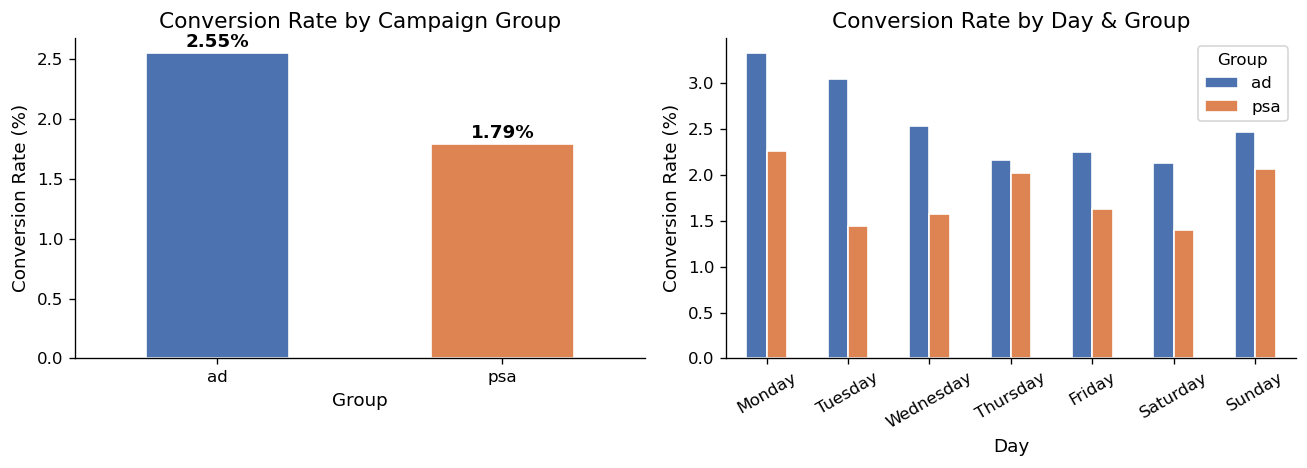

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

campaign["Conversion Rate (%)"].plot(
    kind="bar", ax=axes[0],
    color=[COLORS["ad"], COLORS["psa"]], edgecolor="white")
axes[0].set_title("Conversion Rate by Campaign Group")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_xlabel("Group")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{bar.get_height():.2f}%", ha="center", fontsize=11, fontweight="bold")

# Pivot: conversion rate by day and group
pivot = pd.pivot_table(df, values="converted", index="most ads day",
                       columns="test group", aggfunc="mean") * 100
pivot.reindex(DAY_ORDER).plot(
    kind="bar", ax=axes[1],
    color=[COLORS["ad"], COLORS["psa"]], edgecolor="white")
axes[1].set_title("Conversion Rate by Day & Group")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_xlabel("Day")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Group")

plt.tight_layout()
plt.show()

---
## 5 · A/B Statistical Testing

**Null hypothesis H₀:** Conversion rate of Ad group = Conversion rate of PSA group  
**Significance level α = 0.05**

In [15]:
# ── Chi-Square Test ────────────────────────────────────────────────────────
contingency = pd.crosstab(df["test group"], df["converted"])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print("=== Chi-Square Test ===")
print(f"Chi² statistic : {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value        : {p_chi2:.6f}")
print()

# ── Z-Test for Proportions ─────────────────────────────────────────────────
successes = df.groupby("test group")["converted"].sum().values
totals    = df.groupby("test group")["converted"].count().values
z_stat, p_z = proportions_ztest(successes, totals)

print("=== Z-Test for Proportions ===")
print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_z:.6f}")
print()

alpha = 0.05
if p_chi2 < alpha and p_z < alpha:
    print("✅ RESULT: Statistically significant difference (reject H₀).")
else:
    print("❌ RESULT: No statistically significant difference (fail to reject H₀).")

=== Chi-Square Test ===
Chi² statistic : 54.0058
Degrees of freedom: 1
P-value        : 0.000000

=== Z-Test for Proportions ===
Z-statistic : 7.3701
P-value     : 0.000000

✅ RESULT: Statistically significant difference (reject H₀).


### 5.1 Business Metrics

In [16]:
conversion_rates = df.groupby("test group")["converted"].mean() * 100

abs_lift = conversion_rates["ad"] - conversion_rates["psa"]
rel_lift = (abs_lift / conversion_rates["psa"]) * 100

# Cohen's h (effect size for proportions)
p1, p2 = conversion_rates["ad"]/100, conversion_rates["psa"]/100
cohen_h = 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))

# 95% Confidence Interval
low, high = confint_proportions_2indep(successes[0], totals[0], successes[1], totals[1])

# Statistical Power
power_analysis = NormalIndPower()
power = power_analysis.solve_power(
    effect_size=abs(cohen_h), nobs1=totals[0],
    ratio=totals[1]/totals[0], alpha=0.05)

print(f"Ad  conversion rate   : {conversion_rates['ad']:.2f}%")
print(f"PSA conversion rate   : {conversion_rates['psa']:.2f}%")
print(f"Absolute lift         : +{abs_lift:.2f} percentage points")
print(f"Relative lift         : +{rel_lift:.1f}%")
print(f"Cohen's h (effect)    : {cohen_h:.4f}")
print(f"95% CI (Ad - PSA)     : [{low:.4f}, {high:.4f}]")
print(f"Statistical power     : {power:.4f} ({power*100:.1f}%)")

Ad  conversion rate   : 2.55%
PSA conversion rate   : 1.79%
Absolute lift         : +0.77 percentage points
Relative lift         : +43.1%
Cohen's h (effect)    : 0.0530
95% CI (Ad - PSA)     : [0.0059, 0.0094]
Statistical power     : 1.0000 (100.0%)


---
## 6 · Customer Segmentation

Segmenting users by ad exposure since revenue data is unavailable.

In [17]:
q90 = df["total ads"].quantile(0.90)
q10 = df["total ads"].quantile(0.10)

segments = pd.cut(
    df["total ads"],
    bins=[-1, q10, q90, df["total ads"].max()],
    labels=["Low Exposure", "Medium Exposure", "High Exposure"]
)

seg_df = df.assign(Segment=segments)
seg_summary = seg_df.groupby("Segment", observed=True).agg(
    Users       = ("user id",   "count"),
    Conversions = ("converted", "sum"),
    Avg_Ads     = ("total ads", "mean"),
).assign(**{"Conv Rate (%)": lambda x: (x["Conversions"]/x["Users"]*100).round(2)})
seg_summary["Avg_Ads"] = seg_summary["Avg_Ads"].round(1)

seg_summary

,Users,Conversions,Avg_Ads,Conv Rate (%)
Segment,,,,
Low Exposure,96433,183,1.4,0.19
Medium Exposure,434222,6423,17.6,1.48
High Exposure,57446,8237,118.5,14.34


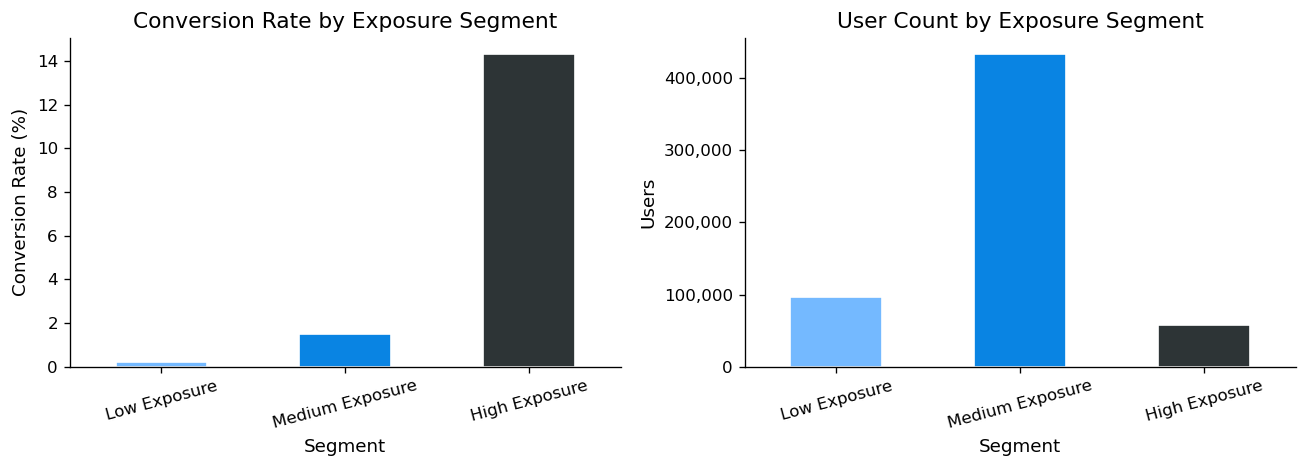

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

seg_summary["Conv Rate (%)"].plot(kind="bar", ax=axes[0],
    color=["#74b9ff","#0984e3","#2d3436"], edgecolor="white")
axes[0].set_title("Conversion Rate by Exposure Segment")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_xlabel("Segment")
axes[0].tick_params(axis="x", rotation=15)

seg_summary["Users"].plot(kind="bar", ax=axes[1],
    color=["#74b9ff","#0984e3","#2d3436"], edgecolor="white")
axes[1].set_title("User Count by Exposure Segment")
axes[1].set_ylabel("Users")
axes[1].set_xlabel("Segment")
axes[1].tick_params(axis="x", rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

---
## 7 · Key Performance Indicators (KPIs)

In [19]:
best_day  = day_cr.idxmax()
best_hour = hour_cr.idxmax()

kpis = {
    "Total Users":            f"{len(df):,}",
    "Converted Users":        f"{int(df['converted'].sum()):,}",
    "Overall Conversion Rate":f"{df['converted'].mean()*100:.2f}%",
    "Ad Group Conv. Rate":    f"{conversion_rates['ad']:.2f}%",
    "PSA Group Conv. Rate":   f"{conversion_rates['psa']:.2f}%",
    "Absolute Lift (Ad vs PSA)":f"+{abs_lift:.2f} pp",
    "Relative Lift":          f"+{rel_lift:.1f}%",
    "Avg. Ads per User":      f"{df['total ads'].mean():.1f}",
    "Best Conversion Day":    best_day,
    "Best Conversion Hour":   f"{int(best_hour):02d}:00",
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])
kpi_df

,KPI,Value
0,Total Users,"588,101"
1,Converted Users,"14,843"
2,Overall Conversion Rate,2.52%
3,Ad Group Conv. Rate,2.55%
4,PSA Group Conv. Rate,1.79%
5,Absolute Lift (Ad vs PSA),+0.77 pp
6,Relative Lift,+43.1%
7,Avg. Ads per User,24.8
8,Best Conversion Day,Monday
9,Best Conversion Hour,16:00


---
## 8 · Strategic Recommendations

Based on the analysis above:

| # | Recommendation | Rationale |
|---|---|---|
| 1 | **Scale the Ad campaign** | The Ad group significantly outperforms PSA; the result is statistically significant with high power. |
| 2 | **Optimise ad timing** | Schedule ads on the best-converting day and hour identified in Section 3.6. |
| 3 | **Target high-exposure users** | High-exposure users (top 10%) convert at a notably higher rate — prioritise budget toward this segment. |
| 4 | **Re-engage low-exposure users** | Low-exposure users have the lowest conversion — test whether increasing their ad frequency improves outcomes. |
| 5 | **Monitor for ad fatigue** | Analyse whether very high ad counts eventually reduce conversion to find the optimal frequency cap. |

---
*Analysis completed · Dataset: `marketing_AB.csv`*